# CSCI450 Project 1
## **Pill Counting**
This projects implements computer vision pipleline to detect and count pills in images. The goal is to analyze images containing multiple types of pills placed at random orientations and accruately determine the total number of pills present. 

The dataset was created by us, with all pills rotated and slightly scaled. This ensured consistency and reproducibility while testing the segmentaion and counting.

**Our Team:**

**- Lyudmyla Buhayenko**

**- Sergei Vorobev**

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, feature, color, exposure, filters, morphology, measure
import os
from skimage.filters import gaussian, median
import warnings
warnings.filterwarnings('ignore')

### Normalization

In [42]:
def imNormalize(image):
    r = image[:,:,0]
    g = image[:,:,1]
    b = image[:,:,2]
    
    r = r - r.min()
    r = r / r.max()
    r = np.uint8(r * 255)
    
    g = g - g.min()
    g = g / g.max()
    g = np.uint8(g * 255)
    
    b = b - b.min()
    b = b / b.max()
    b = np.uint8(b * 255)
    
    return np.stack((r,g,b),axis=2) 

### Segmentation

In [43]:
def segment_pills(image, sigma=1, min_size=150, hole_size=50):
    gray = color.rgb2gray(image)
    smooth = gaussian(gray, sigma=sigma)
    smooth = median(smooth)

    threshold = filters.threshold_otsu(smooth)

    mask = smooth < threshold

    mask = morphology.remove_small_objects(mask, min_size=min_size)
    mask = morphology.remove_small_holes(mask, area_threshold=hole_size)
    #each pill gets different number
    labels = measure.label(mask)

    img_segmented = image.copy()
    img_segmented[~mask] = 0

    return img_segmented, mask, labels


In [44]:
#testing if working
img_00000 = io.imread("img_00000.png")
image_segmented, mask, labels = segment_pills(img_00000)

<Figure size 1500x500 with 0 Axes>

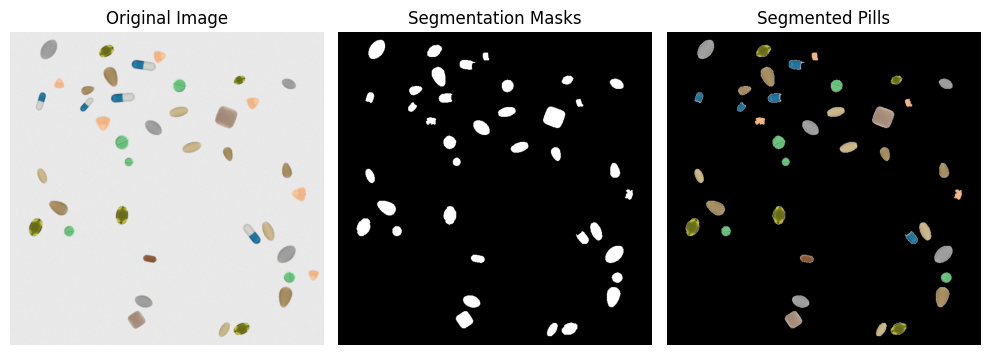

In [45]:
plt.figure(figsize=(15,5))

fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize = (10,5))
ax1.imshow(img_00000)
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(mask, cmap='gray')
ax2.set_title('Segmentation Masks')
ax2.axis('off')

ax3.imshow(image_segmented)
ax3.set_title('Segmented Pills')
ax3.axis('off')

plt.tight_layout()
plt.show()

###  Defining Features

#### Histogram of Oriented Gradients (HOG)

In [11]:
path = 'pill_dataset/images'
imagelist = os.listdir(path)

feature_color_hist = []
feature_hog = []

FileNotFoundError: [Errno 2] No such file or directory: 'pill_dataset/images'

In [ ]:
for i in range(len(imagelist)):
    img = io.imread(path + '/' + imagelist[i])
    #resized_img = resize(img, (HEIGHT, WIDTH), anti_aliasing=True)
    norm_image = exposure.rescale_intensity(img, in_range='image', out_range=(0,255)) # our norm func. works per channel
    hsv_img = color.rgb2hsv(norm_image)

    hog_fd = feature.hog(norm_image, orientations=9, pixels_per_cell=(16, 16),
                cells_per_block=(1, 1), channel_axis=2)
    hist, bins = exposure.histogram(hsv_img[:,:,0], nbins=256)
    
    line = '\rProcessing '+ str(i+1) + ' of '+ str(len(imagelist))
    print(line, end='')

Processing 5 of 15000

KeyboardInterrupt: 

#### Color Histograms

#### Local Binary Patterns (LBP)

#### Gabor Filters

### Extracting Features

In [48]:
def extract_features(image):
    features = {}
    #extracting features
    return features

### Scaling Features

### Splitting data into training and testing set

### Logistic Regression

### Model Evaluation